In [30]:
import pandas as pd

In [31]:
import matplotlib.pyplot as plt

In [32]:
import seaborn as sns

In [33]:
%matplotlib inline

In [34]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
import numpy as np

In [38]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/4. Feature Engineering/Ft Engineering(Feature).csv")

In [39]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,...,Publisher Freq,Developer Freq,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,0.933333,1.000000,0.652664,0.464789,1.000000,...,0.088207,0.047945,2010,0.652664,1.000000,0.464789,1.000000,0,High,2
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,0.966667,0.953740,0.620902,0.281690,0.985787,...,0.088207,0.047945,2010,0.651018,1.033601,0.295353,1.014898,0,High,2
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,0.955556,0.794291,0.861680,0.220657,0.557360,...,0.088207,0.047945,2000,1.084842,0.701708,0.277804,0.718266,0,High,2
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,0.677988,0.780512,0.928279,0.028169,0.541117,...,0.088207,0.047945,2010,1.189320,0.693285,0.036090,0.583115,0,Medium,1
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,0.788889,0.742126,0.633197,0.192488,0.614213,...,1.000000,0.125571,2010,0.853220,0.827640,0.259374,1.053799,1,High,2


In [40]:
df.dtypes # check data types

Game Title               object
Console                  object
Genre                    object
Publisher                object
Developer                object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
EU Sales                float64
Other Sales             float64
Release Year              int64
Publisher Freq          float64
Developer Freq          float64
Decade                    int64
NA Share                float64
EU Share                float64
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
dtype: object

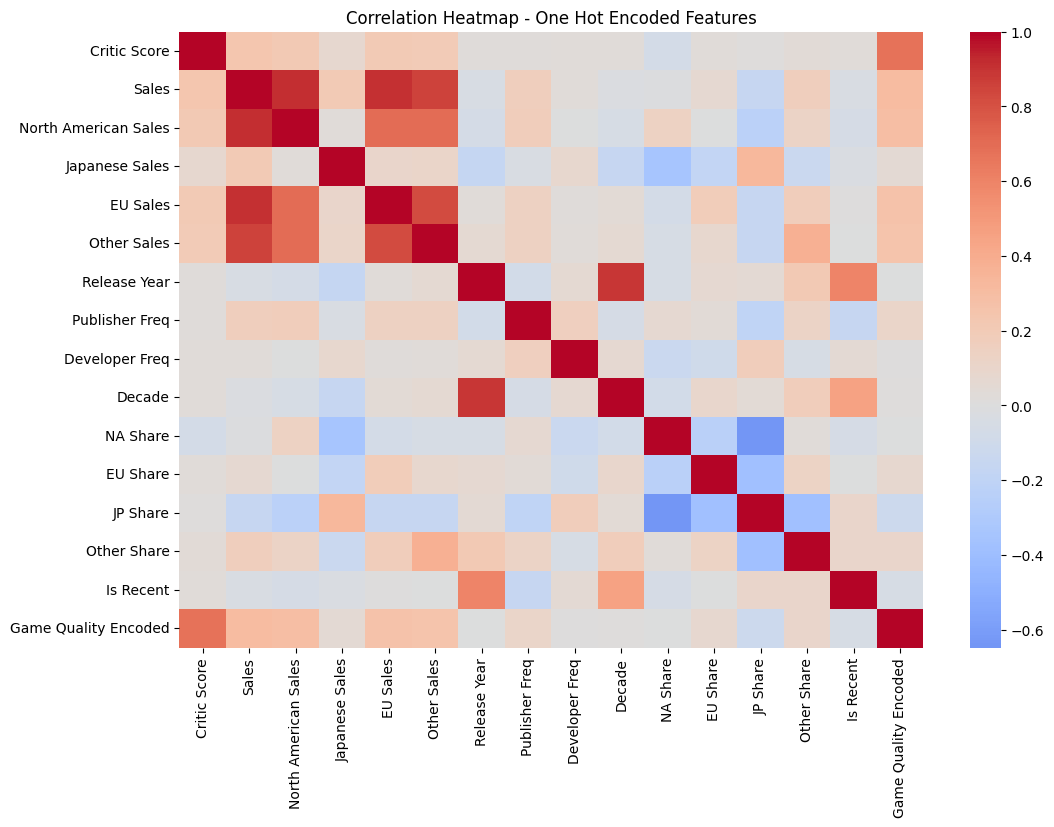

In [41]:
# Correlation Heatmap (EDA step)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - One Hot Encoded Features")
plt.show()

In [42]:
# Variance Threshold

X = df.drop(columns=["Sales"]).select_dtypes(include="number").copy()
y = df["Sales"].astype(float)

# make it finite + numeric
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

vt = VarianceThreshold(threshold=0.001)
X_vt = X.loc[:, vt.fit(X).get_support()]

print("Original features:", X.shape[1])
print("After VarianceThreshold:", X_vt.shape[1])

Original features: 15
After VarianceThreshold: 15


Top MI features:
 Other Share             1.906934
NA Share                1.436286
EU Share                1.376645
North American Sales    1.138731
JP Share                0.789998
Other Sales             0.744448
EU Sales                0.713323
Japanese Sales          0.581478
Publisher Freq          0.136295
Developer Freq          0.082913
Critic Score            0.073549
Game Quality Encoded    0.053085
Release Year            0.048595
Decade                  0.022336
Is Recent               0.017619
dtype: float64


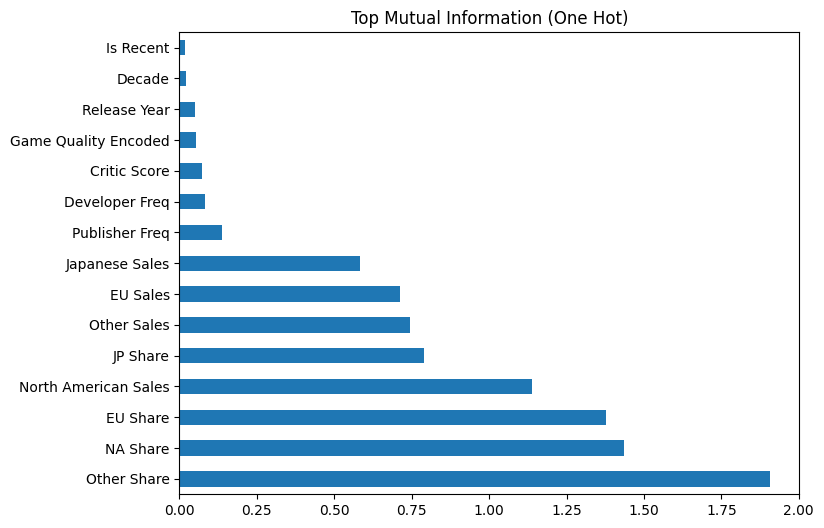

In [43]:
# Mutual Information

mi = mutual_info_regression(X_vt.fillna(0), y)
mi_scores = pd.Series(mi, index=X_vt.columns).sort_values(ascending=False)

print("Top MI features:\n", mi_scores.head(15))

mi_scores.head(15).plot(kind="barh", figsize=(8,6), title="Top Mutual Information (One Hot)")
plt.show()

In [ ]:
# Random Forest Importance

X_train, X_test, y_train, y_test = train_test_split(X_vt.fillna(0), y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_vt.columns).sort_values(ascending=False)

print("Top RF features:\n", rf_importances.head(15))

rf_importances.head(15).plot(kind="barh", figsize=(8,6), title="Random Forest Importance (One Hot)")
plt.show()

In [ ]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/5. Feature Selection/Feature Selection(Feature).csv", index=False)